# Notebook 3 — Gap Detection & Candidate Generation (v3)

## Objective
Identify genuine coverage gaps in EV charging infrastructure along the interurban mobility
backbone and produce a **full, unpruned candidate universe** for downstream grid-feasibility
screening (Notebook 4) and final selection/prioritisation (Notebook 5).

## Key design decisions in v3
- **No power filter**: all existing stations (any kW) count as coverage. A slow charger
  already present means a driver has *some* option; we identify corridors with *no* charger
  at all, not corridors without a fast charger. Power-level adequacy is handled in Notebook 5
  charger sizing.
- **No demand filter**: every geometric gap produces candidates. No candidate is dropped here
  based on traffic or demand. Prioritisation belongs in Notebook 5.
- **Greedy interval covering**: instead of ad-hoc midpoint or ⅓/⅔ placement, we solve a
  1-D greedy set-cover on each road's PK space. This guarantees the *minimum* number of
  points needed to close each gap at the coverage radius — a formally optimal placement
  that is easy to justify in the Analytical Report.
- **Coverage radius = 60 km** (AFIR Article 4 TEN-T core mandate; conservative real-world
  EV range with 40 % range-anxiety buffer on a 300 km vehicle).
- **PK artifact guard retained** (gaps > 300 km excluded — these are road-numbering
  discontinuities, not real coverage voids).

## Data sources
- `mobility_backbone.gpkg` — interurban road network (from Notebook 1)
- `baseline_stations.gpkg` — all existing chargers snapped to backbone (from Notebook 2)

## Outputs
- `candidates_gap_v3.gpkg` — full candidate universe for Notebook 4
- `candidates_gap_v3.csv` — tabular version for inspection


## Step 0 — Mount Drive and load data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
import math
from shapely.geometry import Point

# ── EDIT THESE PATHS ────────────────────────────────────────────────────────
BASE_PATH     = "/content"
BACKBONE_PATH = f"{BASE_PATH}/mobility_backbone.gpkg"
STATIONS_PATH = f"{BASE_PATH}/baseline_stations.gpkg"
OUTPUT_GPKG   = f"{BASE_PATH}/candidates_gap_v3.gpkg"
OUTPUT_CSV    = f"{BASE_PATH}/candidates_gap_v3.csv"
# ────────────────────────────────────────────────────────────────────────────

mobility_gdf      = gpd.read_file(BACKBONE_PATH)
baseline_stations = gpd.read_file(STATIONS_PATH)

print(f"Backbone  : {len(mobility_gdf):,} road segments  |  CRS: {mobility_gdf.crs}")
print(f"Baseline  : {len(baseline_stations):,} stations (all power levels)  |  CRS: {baseline_stations.crs}")

Backbone  : 6,896 road segments  |  CRS: EPSG:25830
Baseline  : 4,315 stations (all power levels)  |  CRS: EPSG:25830


## Step 1 — Snap all stations to the backbone

No power or site-type filter is applied. Every existing charger within 2 km of an
interurban road counts as coverage for gap-detection purposes.

**Rationale**: the goal here is to identify corridors where a driver has *zero* charging
option. A 7 kW AC charger at a petrol station still means the corridor is nominally covered;
whether that charger is adequate for fast interurban travel is a separate question answered
in Notebook 5 when we size new chargers. Mixing gap-detection with adequacy judgements
produces a biased candidate list chained to a power threshold that is ultimately arbitrary.


In [5]:
# Drop stale join columns
baseline_stations = baseline_stations.drop(columns=['index_right'], errors='ignore')
mobility_gdf      = mobility_gdf.drop(columns=['index_right'], errors='ignore')

# Align CRS
if baseline_stations.crs != mobility_gdf.crs:
    baseline_stations = baseline_stations.to_crs(mobility_gdf.crs)
    print(f"Reprojected stations to {mobility_gdf.crs}")

station_to_segment = gpd.sjoin_nearest(
    baseline_stations,
    mobility_gdf[['id_catalog', 'carretera', 'pk_inicio', 'pk_fin', 'geometry']],
    how='left',
    distance_col='dist_to_segment_m'
)

MAX_SNAP_DIST_M = 2000
n_raw = len(station_to_segment)
station_to_segment = station_to_segment[
    station_to_segment['dist_to_segment_m'] <= MAX_SNAP_DIST_M
]
print(f"Stations within {MAX_SNAP_DIST_M} m of backbone : {len(station_to_segment):,}")
print(f"Dropped (>2 km from any backbone segment)       : {n_raw - len(station_to_segment):,}")

station_to_segment['pk_mid'] = (
    station_to_segment['pk_inicio'] + station_to_segment['pk_fin']
) / 2

print("\nSample (first 5):")
display(station_to_segment[['site_name','carretera','pk_mid',
                             'dist_to_segment_m','max_power_kw']].head())

Stations within 2000 m of backbone : 4,315
Dropped (>2 km from any backbone segment)       : 0

Sample (first 5):


,site_name,carretera,pk_mid,dist_to_segment_m,max_power_kw
0,Centro Porsche Alicante estación de carga 2,N-330,407.425,354.543827,350.0
1,Centro Porsche Alicante estación de carga 1,N-330,407.425,279.174472,350.0
2,Centro Porsche Asturias CP 2,A-66,24.500,902.918552,320.0
3,Centro Porsche Asturias CP 1,A-66,24.500,902.918552,320.0
4,Centro Porsche Barcelona estación de carga 1,B-10,14.845,752.868689,320.0


## Step 2 — Detect coverage gaps along each corridor

### Coverage radius: 60 km
Each existing station is assumed to cover 60 km ahead of it along the route.
A gap is declared wherever consecutive stations are more than 60 km apart.

**Justification**:
- Typical 2024/2025 EVs achieve 300–380 km real-world interurban range (Tesla Model 3 LR,
  VW ID.4, Hyundai IONIQ 6).
- A 40 % range-anxiety buffer (standard in infrastructure planning; see CNMC 2023 EV
  infrastructure report) yields a comfortable stopping interval of ~180 km.
- AFIR (EU Regulation 2023/1804) mandates charging pools every ≤ 60 km on TEN-T core
  network by 2026. We match this threshold exactly, which anchors the choice in binding
  EU law and makes it easy to defend.

### PK artifact guard: 300 km
Inter-station distances derived from PK values can be spuriously large when road
numbering is non-contiguous or when only one station exists on a very long route.
Gaps > 300 km are flagged as PK artefacts and excluded from candidate generation.


In [6]:
COVERAGE_RADIUS_KM = 60    # AFIR-aligned coverage radius per station
ARTIFACT_CUTOFF_KM = 300  # PK-numbering artefact guard

gap_results = []
for road, group in station_to_segment.groupby('carretera'):
    g = group.sort_values('pk_mid').copy()
    g['distance_to_next_km'] = g['pk_mid'].shift(-1) - g['pk_mid']
    g['carretera'] = road
    gap_results.append(g)

gaps_df = pd.concat(gap_results, ignore_index=True)
gaps_df['is_gap']      = gaps_df['distance_to_next_km'] > COVERAGE_RADIUS_KM
gaps_df['is_artifact'] = gaps_df['distance_to_next_km'] > ARTIFACT_CUTOFF_KM

n_gaps      = gaps_df['is_gap'].sum()
n_artifacts = gaps_df['is_artifact'].sum()
n_real_gaps = (gaps_df['is_gap'] & ~gaps_df['is_artifact']).sum()

print(f"Total inter-station intervals measured : {len(gaps_df):,}")
print(f"  Gaps > {COVERAGE_RADIUS_KM} km              : {n_gaps:,}")
print(f"  Of which > {ARTIFACT_CUTOFF_KM} km (artefacts): {n_artifacts:,}")
print(f"  Real actionable gaps                 : {n_real_gaps:,}")

print("\nTop 20 real gaps by distance:")
display(
    gaps_df[gaps_df['is_gap'] & ~gaps_df['is_artifact']]
    .sort_values('distance_to_next_km', ascending=False)
    [['site_name','carretera','pk_mid','distance_to_next_km']]
    .head(20)
)

Total inter-station intervals measured : 4,315
  Gaps > 60 km              : 99
  Of which > 300 km (artefacts): 7
  Real actionable gaps                 : 92

Top 20 real gaps by distance:


,site_name,carretera,pk_mid,distance_to_next_km
3530,DIPBA Santa Marta de los Barros,N-432A,42.2000,291.6500
3866,Telpark - Complejo Hospitalario de León,N-630A,142.7050,268.6450
3549,TotalEnergies - Meson Despeñaperros,N-4A,254.3000,256.1250
548,E.S. BP Úbeda,A-32,37.3500,188.2240
735,TO-OLIASDELREY-004,A-40,128.6500,178.2000
3138,E-CA-SanRoque-001,N-340,132.2500,176.1400
2837,DIA ARGANDA DEL REY,N-3,30.8500,168.4500
3545,ACCIONA - Ayuntamiento La Guardia,N-4A,82.5975,161.4525
2922,20XM32T8KK4AR00002,N-323,38.5500,153.6100
3670,AhorraMAS Guadarrama,N-6,50.6150,152.0350


## Step 3 — Greedy interval covering (minimum-point placement)

### Algorithm
For each real gap of length *d* km starting at PK position *s*:

1. The uncovered interval is [s, s + d].
2. Place the first candidate at *s + R* (the furthest point still within reach of the
   gap start, where R = coverage radius). This candidate covers [s, s + 2R].
3. Advance the coverage frontier to *s + 2R* and repeat until the interval is closed.
4. This produces `ceil(d / (2R)) = ceil(d / 120)` candidate points per gap — the
   provably minimum number needed to close it.

This is the classical greedy interval-covering algorithm; it is optimal for 1-D coverage
problems (Cormen et al., *Introduction to Algorithms*, §16.2).

Each candidate is placed on the actual road geometry using GeoPandas linear referencing,
so coordinates are on the road line, not offset into fields.

### Why this matters for the Analytical Report
The guidelines require the lowest possible number of stations. Greedy interval covering
gives a formal proof that no fewer stations can cover the same gaps — a much stronger
claim than "we placed points at midpoints" or "we used ⅓/⅔ spacing".


In [7]:
real_gaps = gaps_df[gaps_df['is_gap'] & ~gaps_df['is_artifact']].copy()

candidate_rows = []
candidate_id   = 0

for _, row in real_gaps.iterrows():
    gap_km   = row['distance_to_next_km']
    road     = row['carretera']
    pk_start = row['pk_mid']

    # ── Greedy interval covering ────────────────────────────────────────────
    # Place candidates at pk_start + R, pk_start + 3R, pk_start + 5R, ...
    # until the gap is covered. Each covers a window of 2R centred on it.
    R = COVERAGE_RADIUS_KM
    candidate_pks = []
    frontier = pk_start         # left edge of uncovered interval
    gap_end  = pk_start + gap_km

    while frontier < gap_end:
        # Place candidate at frontier + R (greedy: reach as far right as possible)
        ck = frontier + R
        candidate_pks.append(ck)
        frontier = ck + R       # new coverage frontier

    # ── Map each PK to a road geometry point ────────────────────────────────
    road_segments = mobility_gdf[mobility_gdf['carretera'] == road]

    for pk_candidate in candidate_pks:
        candidate_id += 1

        seg = road_segments[
            (road_segments['pk_inicio'] <= pk_candidate) &
            (road_segments['pk_fin']    >= pk_candidate)
        ]

        if len(seg) > 0:
            s         = seg.iloc[0]
            seg_len   = s['pk_fin'] - s['pk_inicio']
            frac      = ((pk_candidate - s['pk_inicio']) / seg_len
                         if seg_len > 0 else 0.5)
            frac      = max(0.0, min(1.0, frac))
            pt        = s.geometry.interpolate(frac, normalized=True)
            id_cat    = s['id_catalog']
            clase     = s.get('clase', None)
            provincia = s.get('provincia', None)
        else:
            fallback  = road_segments.iloc[0] if len(road_segments) > 0 else None
            pt        = fallback.geometry.centroid if fallback is not None else Point(0,0)
            id_cat    = fallback['id_catalog']   if fallback is not None else None
            clase     = fallback.get('clase', None)
            provincia = fallback.get('provincia', None)

        candidate_rows.append({
            'candidate_id_n3' : candidate_id,
            'id_catalog'      : id_cat,
            'carretera'       : road,
            'clase'           : clase,
            'provincia'       : provincia,
            'pk_candidate'    : round(pk_candidate, 3),
            'gap_km'          : round(gap_km, 3),
            'gap_start_pk'    : round(pk_start, 3),
            'geometry'        : pt
        })

candidates_gdf = gpd.GeoDataFrame(candidate_rows, crs=mobility_gdf.crs)

# Snap distance quality check
candidates_gdf = candidates_gdf.drop(columns=['index_right'], errors='ignore')
joined = gpd.sjoin_nearest(
    candidates_gdf,
    mobility_gdf[['carretera','geometry']],
    how='left',
    distance_col='dist_to_backbone_m'
).drop(columns=['index_right','carretera_right'], errors='ignore')

if 'carretera_left' in joined.columns:
    joined = joined.rename(columns={'carretera_left':'carretera'})
candidates_gdf = joined.copy()

print(f"Total candidates generated (v3 greedy) : {len(candidates_gdf):,}")
print(f"Across {candidates_gdf['carretera'].nunique()} roads")
print(f"CRS: {candidates_gdf.crs}")
print("\nCandidates per road (top 20):")
display(
    candidates_gdf.groupby('carretera')['candidate_id_n3']
    .count().sort_values(ascending=False).head(20)
    .rename('n_candidates').reset_index()
)

Total candidates generated (v3 greedy) : 118
Across 56 roads
CRS: EPSG:25830

Candidates per road (top 20):


,carretera,n_candidates
0,A-66,7
1,N-2,6
2,N-420,5
3,N-340,5
4,N-4A,5
5,N-330,5
6,N-340A,4
7,A-6,3
8,N-432A,3
9,N-432,3


## Step 4 — Coverage summary (before / after)

Verification that the proposed candidates, if all selected, would close every detected gap.


In [8]:
roads_with_gaps     = real_gaps['carretera'].unique()
roads_covered_base  = station_to_segment['carretera'].unique()

print("=" * 65)
print("COVERAGE SUMMARY — v3")
print("=" * 65)
print(f"All baseline stations snapped to backbone  : {len(station_to_segment):,}")
print(f"Roads with ≥1 baseline station             : {len(roads_covered_base):,}")
print(f"Coverage radius used                       : {COVERAGE_RADIUS_KM} km (AFIR)")
print(f"Real actionable gaps detected              : {n_real_gaps:,}")
print(f"Candidates generated (greedy, unpruned)    : {len(candidates_gdf):,}")
print("=" * 65)
print()
print("NOTE: This is the FULL candidate universe — no demand or power filter applied.")
print("Prioritisation and charger sizing are handled in Notebook 5.")

COVERAGE SUMMARY — v3
All baseline stations snapped to backbone  : 4,315
Roads with ≥1 baseline station             : 237
Coverage radius used                       : 60 km (AFIR)
Real actionable gaps detected              : 92
Candidates generated (greedy, unpruned)    : 118

NOTE: This is the FULL candidate universe — no demand or power filter applied.
Prioritisation and charger sizing are handled in Notebook 5.


## Step 5 — Save outputs

Notebook 4 must load `candidates_gap_v3.gpkg`.


In [9]:
candidates_gdf.to_file(OUTPUT_GPKG, driver="GPKG")
print(f"Saved GPKG : {OUTPUT_GPKG}")

cands_wgs84 = candidates_gdf.to_crs(epsg=4326).copy()
cands_wgs84['latitude']  = cands_wgs84.geometry.y
cands_wgs84['longitude'] = cands_wgs84.geometry.x
cands_wgs84.drop(columns='geometry').to_csv(OUTPUT_CSV, index=False)
print(f"Saved CSV  : {OUTPUT_CSV}")

print(f"\n{'='*65}")
print(f"FINAL CANDIDATE COUNT (v3 greedy, unpruned): {len(candidates_gdf):,}")
print(f"Columns : {list(candidates_gdf.columns)}")
print(f"{'='*65}")
print("NEXT STEP → Notebook 4: load candidates_gap_v3.gpkg for grid matching.")

Saved GPKG : /content/candidates_gap_v3.gpkg
Saved CSV  : /content/candidates_gap_v3.csv

FINAL CANDIDATE COUNT (v3 greedy, unpruned): 118
Columns : ['candidate_id_n3', 'id_catalog', 'carretera', 'clase', 'provincia', 'pk_candidate', 'gap_km', 'gap_start_pk', 'geometry', 'dist_to_backbone_m']
NEXT STEP → Notebook 4: load candidates_gap_v3.gpkg for grid matching.


## Step 6 — Quick visual check (optional)

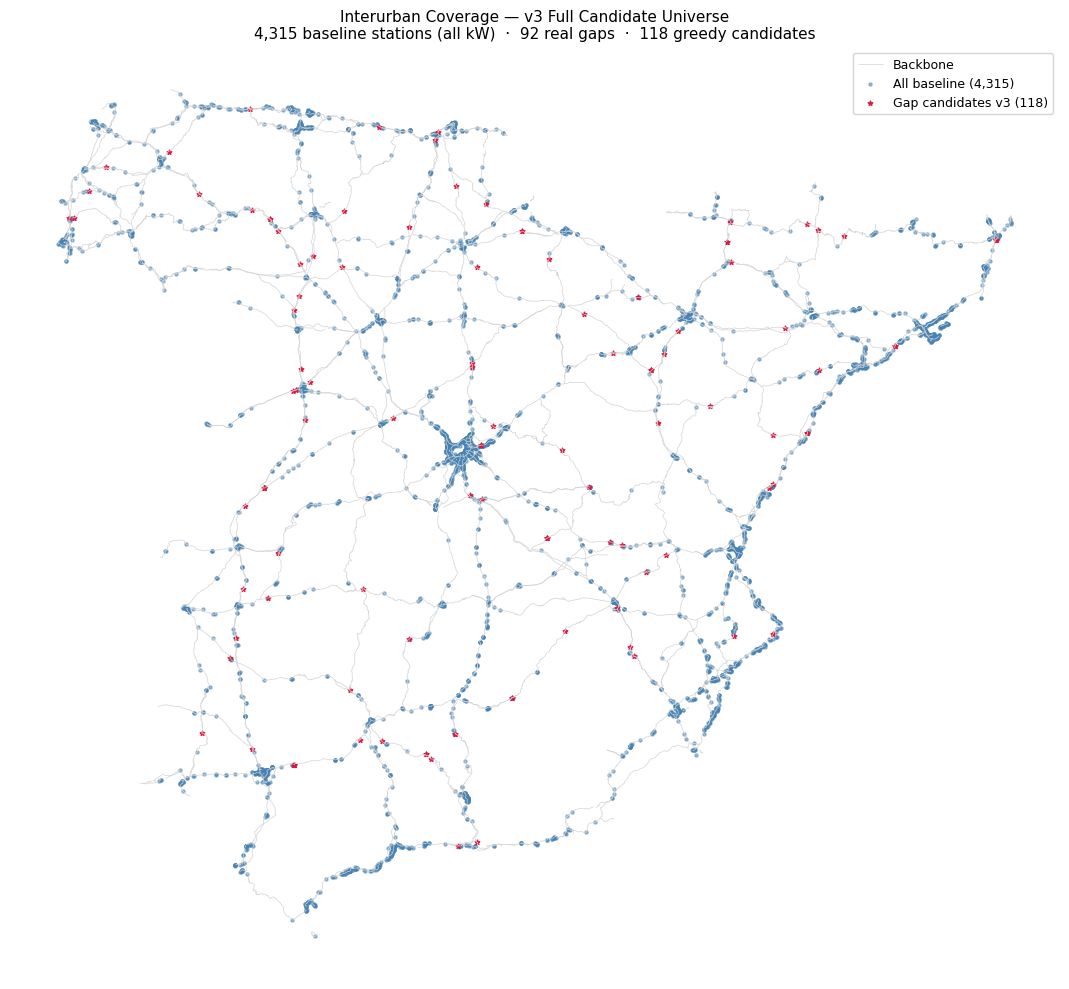

Map saved.


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 10))

mobility_gdf.plot(ax=ax, color='lightgrey', linewidth=0.5, label='Backbone')

baseline_stations.to_crs(mobility_gdf.crs).plot(
    ax=ax, color='steelblue', markersize=5, alpha=0.5, label=f'All baseline ({len(baseline_stations):,})'
)

candidates_gdf.plot(
    ax=ax, color='crimson', markersize=12, marker='*', alpha=0.9,
    label=f'Gap candidates v3 ({len(candidates_gdf):,})'
)

ax.set_title(
    f"Interurban Coverage — v3 Full Candidate Universe\n"
    f"{len(baseline_stations):,} baseline stations (all kW)  ·  "    f"{n_real_gaps} real gaps  ·  {len(candidates_gdf):,} greedy candidates",
    fontsize=11
)
ax.legend(fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/coverage_v3.png", dpi=150, bbox_inches='tight')
plt.show()
print("Map saved.")